# Glacier outline from InSAR coherence time series

## ESA ClouDInSAR

**Authors:**  
_Mattia Callegari, Eurac Research_  

**Release Date:**  
April 17, 2026

This notebook demonstrates how to generate a Sentinel-1 InSAR coherence time series using openEO. It also shows how to derive glacier outlines for all glaciers in South Tyrol by analyzing Sentinel-1 InSAR coherence data.

In [1]:
import openeo

import glob
import os

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge

import geopandas as gpd
import numpy as np

## 1) Input setting and preparation

<Axes: >

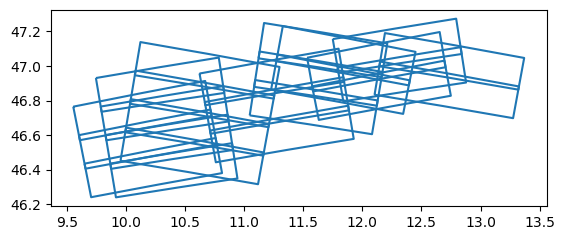

In [2]:
start_date, end_date = ["2023-07-01", "2023-09-30"]

output_folder = './glaciers'

bursts_filename = './auxdata/s1_bursts_glacierSouthTyrol.geojson' # Extracted from the burst id map (https://sar-mpc.eu/sar-mpc-products/)
bursts = gpd.read_file(bursts_filename)
bursts.boundary.plot()

In [3]:
url = "https://openeo.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

Authenticated using refresh token.


## 2) Multi-temporal mosaic of coherence

For each burst compute the InSAR coherence time series and then the multitemporal max

In [4]:
job_list = []

for idx, b in bursts.iterrows():

    datacube = connection.datacube_from_process(
        "sentinel1_sar_coherence",
        namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
        **{
            "temporal_extent": [start_date, end_date],
            "temporal_baseline": 12,
            "burst_id": int(b['burst_id']),
            "sub_swath": b['subswath_name'],
            "coherence_window_az": 7,
            "coherence_window_rg": 22,
            "polarization": "VV"
        }
    )

    datacube = datacube.reduce_dimension(dimension='t', reducer='max')
    
    datacube = datacube.save_result(format='GTiff')
    
    job = datacube.create_job(
        title=f"sar_coherence_T{b['relative_orbit_number']}_{b['subswath_name']}_{b['burst_id']}"
    )
    job.start()
    job_list.append(job)    

Check the status of the jobs

In [6]:
connection.list_jobs()

[{'created': '2026-04-17T06:38:21Z',
  'id': 'j-260417063821444694a9503896a3321a',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359502',
  'updated': '2026-04-17T07:38:40Z'},
 {'created': '2026-04-17T06:38:03Z',
  'id': 'j-26041706380348b1942a76f90ce5b146',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359501',
  'updated': '2026-04-17T07:36:36Z'},
 {'created': '2026-04-17T06:37:40Z',
  'id': 'j-2604170637404150b7fee7f5dceaf7e8',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359500',
  'updated': '2026-04-17T07:36:38Z'},
 {'created': '2026-04-17T06:37:22Z',
  'id': 'j-260417063722487a98486a5b5636c15b',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359499',
  'updated': '2026-04-17T07:38:42Z'},
 {'created': '2026-04-17T06:37:00Z',
  'id': 'j-2604170637004c40bf0529186de2a188',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359499',
  'updated': '2026-04-17T07:35:41Z'},
 {'created': '2026-04-17T06:36:42Z',
  'id': 'j-26041706364248d1949b3be5ae73cf6c',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359498',
  'updated': '2026-04-17T07:34:51Z'},
 {'created': '2026-04-17T06:36:18Z',
  'id': 'j-2604170636184d889ce674f84e1dbbea',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW3_249436',
  'updated': '2026-04-17T07:27:37Z'},
 {'created': '2026-04-17T06:35:43Z',
  'id': 'j-2604170635434f3ba54c1fbff18403f9',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249436',
  'updated': '2026-04-17T07:30:23Z'},
 {'created': '2026-04-17T06:35:22Z',
  'id': 'j-2604170635224c9a8c72e3a2d444b04c',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249436',
  'updated': '2026-04-17T07:21:34Z'},
 {'created': '2026-04-17T06:35:05Z',
  'id': 'j-26041706350541adab7996a9377820c9',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW3_249435',
  'updated': '2026-04-17T07:23:25Z'},
 {'created': '2026-04-17T06:34:24Z',
  'id': 'j-2604170634244e88a45ce1e2c49a8f80',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249435',
  'updated': '2026-04-17T07:21:36Z'},
 {'created': '2026-04-17T06:33:57Z',
  'id': 'j-2604170633574049b6c9491363315edf',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249435',
  'updated': '2026-04-17T07:21:38Z'},
 {'created': '2026-04-17T06:33:39Z',
  'id': 'j-26041706333948b5a7ebfa8a2cd20d37',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249434',
  'updated': '2026-04-17T07:20:49Z'},
 {'created': '2026-04-17T06:33:11Z',
  'id': 'j-2604170633114aa18eec0b48c16b0262',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249434',
  'updated': '2026-04-17T07:21:40Z'},
 {'created': '2026-04-17T06:32:51Z',
  'id': 'j-260417063251435785b519baed25212a',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T95_IW3_202702',
  'updated': '2026-04-17T07:01:45Z'},
 {'created': '2026-04-17T06:32:17Z',
  'id': 'j-2604170632174bad88569f4cafa6eb42',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T95_IW3_202701',
  'updated': '2026-04-17T07:05:25Z'},
 {'created': '2026-04-17T06:31:49Z',
  'id': 'j-2604170631494642a073224bdf406101',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T95_IW2_202701',
  'updated': '2026-04-17T07:06:40Z'},
 {'created': '2026-04-17T06:31:05Z',
  'id': 'j-26041706310544a5899c50e9d0303ace',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T95_IW3_202700',
  'updated': '2026-04-17T07:04:39Z'},
 {'created': '2026-04-17T06:30:47Z',
  'id': 'j-26041706304743d9be8ee1976d8f7b7c',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T95_IW2_202700',
  'updated': '2026-04-17T07:01:47Z'},
 {'created': '2026-04-17T06:30:28Z',
  'id': 'j-26041

## 3) Download the results

If in the same session where the jobs were launched, the results can be downloaded directly with:

In [7]:
if np.all([j.status() == 'finished' for j in job_list]):
    for j in job_list:
        j.get_results().download_file(
            os.path.join(output_folder, f'{j.describe()['title']}.tif')
        )

Otherwise, if in a new session, the jobs need to be retrieved using some filters (see example below for a filter on the creation date):

```python
from datetime import datetime
job_create_date = datetime.strptime('2026-03-03T14:39:00Z', "%Y-%m-%dT%H:%M:%SZ")
job_list = [connection.job(j['id']) for j in connection.list_jobs() if datetime.strptime(j['created'], "%Y-%m-%dT%H:%M:%SZ") > job_create_date]
```

## 4) Classify the glaciers

Reproject all to UTM32N with `gdalwarp`

In [8]:
coh_max_filenames = []
for f in glob.glob(os.path.join(output_folder, '*.tif')):
    with rasterio.open(f) as src:
        if src.crs.to_epsg() != 32632:
            target_filename = f[:-4] + '_EPSG32632.tif'
            cmd = f'gdalwarp -t_srs EPSG:32632 -r bilinear -tr 10 10 {f} {target_filename}'
            os.system(cmd)
            coh_max_filenames.append(target_filename)
        else:
            coh_max_filenames.append(f)

Creating output file that is 9487P x 5020L.
Using internal nodata values (e.g. nan) for image /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/sar_coherence_T117_IW3_249436.tif.
Copying nodata values from source /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/sar_coherence_T117_IW3_249436.tif to destination /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/sar_coherence_T117_IW3_249436_EPSG32632.tif.
Processing /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/sar_coherence_T117_IW3_249436.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 10893P x 5512L.
Using internal nodata values (e.g. nan) for image /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/sar_coherence_T95_I

Mosaic computing the max for overlapping pixels

In [9]:
datasets = [rasterio.open(f) for f in coh_max_filenames]

mosaic, transform = merge(
    datasets,
    method='max'
)

meta = datasets[0].meta.copy()
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

coh_max_mosaic_filename = os.path.join(output_folder, "coh_max_mosaic.tif")
with rasterio.open(coh_max_mosaic_filename, "w", **meta) as dst:
    dst.write(mosaic)

Mask the coherence mosaic with the glacier inventory 1997 and apply a threshold based classification

In [10]:
mask_filename = "./auxdata/SGIhom_1997_v2025.shp"
glacier_mask = gpd.read_file(mask_filename).to_crs(meta['crs'])
glacier_mask = glacier_mask.geometry.values

with rasterio.open(coh_max_mosaic_filename) as src:

    coh_max_masked, coh_max_masked_transform = mask(
        src,
        shapes=glacier_mask,
        crop=True,
    )

    coh_th = coh_max_masked < 0.5

    coh_th_meta = src.meta.copy()
    coh_th_meta.update({
        "height": coh_th.shape[1],
        "width":  coh_th.shape[2],
        "transform": coh_max_masked_transform,
        "nodata": 0
    })

    classmap_filename = os.path.join(output_folder, 'coh_th_masked.tif')
    with rasterio.open(classmap_filename, "w", **coh_th_meta) as dst:
        dst.write(coh_th)

Convert in polygon the classification map

In [12]:
os.system(
    f'gdal_polygonize.py {classmap_filename} -f "GeoJSON" {os.path.join(output_folder, "glacier_outline.geojson")}'
)

0...10...20...30...40...50...60...70...80...90...Creating output /home/mcallegari/PROJECT_DATA/ESA_ClouDInSAR/Case_studies/InSAR_coherence_glaciers/openeo_coh_glaciers/glacier_outline.geojson of format GeoJSON.
100 - done.


0